# Algerian E-commerce Dataset Analysis
Analysis of sales history with focus on:
- Return rate
- Return rate by wilaya and region
- Average distance per command
- Average time per command

In [35]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('algerie_ecommerce_dataset_vf.csv')


# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (220000, 14)

Column names:
['Tracking', 'Categorie', 'Produit', 'date expédition', 'date première tentative', 'date livraison/échec', 'date dernier statut', 'ID expediteur', 'depart commune', 'depart wilaya', 'stop desk?', 'destination commune', 'destination wilaya', 'dernier statut']

First few rows:


,Tracking,Categorie,Produit,date expédition,date première tentative,date livraison/échec,date dernier statut,ID expediteur,depart commune,depart wilaya,stop desk?,destination commune,destination wilaya,dernier statut
0,yal-S08QPE,Maison et jardin,Cuisine & salle à manger,2024/05/09 17:11,2024/05/10 13:11,2024/05/11 09:11,2024/05/11 10:11,expyal-86560,Draria,Alger,Non,Hassi Dahou,Sidi Bel Abbès,Livré
1,yal-R2W5JR,Quincaillerie,Plomberie,2025/08/09 12:48,2025/08/09 12:48,2025/08/09 17:48,2025/08/09 20:48,expyal-90075,Boufarik,Blida,Non,Ibn Ziad,Constantine,Livré
2,yal-1N0UIH,Arts et loisirs,Fêtes & événements,2025/06/22 16:06,2025/06/24 08:06,2025/06/24 10:06,2025/06/24 10:06,expyal-81482,Blida,Blida,Non,Kouba,Alger,Retourné au vendeur
3,yal-13V2P3,Vêtements et accessoires,Vêtements,2024/11/16 17:31,2024/11/16 16:31,2024/11/16 11:31,2024/11/16 14:31,expyal-15424,Aïn Arnat,Sétif,Oui,Bougara,Blida,Livré
4,yal-LEX6ML,Vêtements et accessoires,Accessoires chaussures,2024/04/25 18:47,2024/04/28 11:47,2024/04/28 11:47,2024/04/28 13:47,expyal-31450,Batna,Batna,Oui,El Khroub,Constantine,Livré


In [36]:
# Data cleaning and exploration
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("Status values:")
print(df['dernier statut'].value_counts())
print("\n" + "="*80)
print("Unique wilayas (origin):")
print(sorted(df['depart wilaya'].unique()))
print(f"\nTotal unique wilayas: {df['depart wilaya'].nunique()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Tracking                 220000 non-null  object
 1   Categorie                220000 non-null  object
 2   Produit                  220000 non-null  object
 3   date expédition          220000 non-null  object
 4   date première tentative  219070 non-null  object
 5   date livraison/échec     219082 non-null  object
 6   date dernier statut      220000 non-null  object
 7   ID expediteur            220000 non-null  object
 8   depart commune           220000 non-null  object
 9   depart wilaya            220000 non-null  object
 10  stop desk?               220000 non-null  object
 11  destination commune      220000 non-null  object
 12  destination wilaya       220000 non-null  object
 13  dernier statut           220000 non-null  object
dtypes: obj

In [37]:
# Define the 4 regions of Algeria (48 wilayas officielles)
regions_mapping = {
    # Centre (10 wilayas)
    'Alger': 'centre',
    'Blida': 'centre',
    'Boumerdès': 'centre',
    'Tipaza': 'centre',
    'Médéa': 'centre',
    'Aïn Defla': 'centre',
    'Bouira': 'centre',
    'Tizi Ouzou': 'centre',
    'Béjaïa': 'centre',
    'Chlef': 'centre',
    "M'Sila": 'centre', 
    
    # Est (14 wilayas)
    'Constantine': 'est',
    'Annaba': 'est',
    'Skikda': 'est',
    'Jijel': 'est',
    'Sétif': 'est',
    'Batna': 'est',
    'Khenchela': 'est',
    'Oum El Bouaghi': 'est',
    'Tébessa': 'est',
    'Guelma': 'est',
    'Souk Ahras': 'est',
    'Mila': 'est',
    'Bordj Bou Arreridj': 'est',
    'El Tarf': 'est',
    
    # Ouest (11 wilayas)
    'Oran': 'ouest',
    'Tlemcen': 'ouest',
    'Sidi Bel Abbès': 'ouest',
    'Mostaganem': 'ouest',
    'Mascara': 'ouest',
    'Relizane': 'ouest',
    'Saïda': 'ouest',
    'Tiaret': 'ouest',
    'Tissemsilt': 'ouest',
    'Aïn Témouchent': 'ouest',
    'Naâma': 'ouest',
    
    # Sud (13 wilayas)
    'Adrar': 'sud',
    'Tamanrasset': 'sud',
    'Illizi': 'sud',
    'Tindouf': 'sud',
    'Béchar': 'sud',
    'El Oued': 'sud',
    'Ouargla': 'sud',
    'Ghardaïa': 'sud',
    'Laghouat': 'sud',
    'Biskra': 'sud',
    'El Bayadh': 'sud',
    'Djelfa': 'sud',
    
}

# Add region column
df['region'] = df['depart wilaya'].map(regions_mapping)

# Check for unmapped wilayas
unmapped = df[df['region'].isna()]['depart wilaya'].unique()
if len(unmapped) > 0:
    print(f"Unmapped wilayas: {unmapped}")
else:
    print("All wilayas are properly mapped to regions")

print(f"\nRegion distribution:\n{df['region'].value_counts()}")

All wilayas are properly mapped to regions

Region distribution:
region
centre    118913
ouest      42816
est        37798
sud        20473
Name: count, dtype: int64


In [38]:
from math import radians, sin, cos, sqrt, atan2

# Approximate coordinates (latitude, longitude) for each wilaya's capital (48 wilayas officielles)
wilaya_coordinates = {
    # Centre
    'Alger': (36.7538, 3.0588),
    'Blida': (36.4700, 2.8280),
    'Boumerdès': (36.7575, 3.4675),
    'Tipaza': (36.5950, 2.4483),
    'Médéa': (36.3882, 2.7547),
    'Aïn Defla': (36.2667, 1.9667),
    'Bouira': (36.3667, 4.7667),
    'Tizi Ouzou': (36.7167, 4.0667),
    'Béjaïa': (36.7567, 5.0833),
    'Chlef': (36.1667, 1.3167),
    "M'Sila": (35.7058, 4.5419),
    # Est
    'Constantine': (36.3675, 6.6159),
    'Annaba': (36.9000, 7.7600),
    'Skikda': (36.8764, 6.9053),
    'Jijel': (36.8169, 5.7764),
    'Sétif': (36.1925, 5.4089),
    'Batna': (35.5586, 5.8073),
    'Khenchela': (35.4319, 7.1439),
    'Oum El Bouaghi': (35.8733, 7.1089),
    'Tébessa': (35.4047, 8.1244),
    'Guelma': (36.4667, 7.4333),
    'Souk Ahras': (35.1908, 7.6578),
    'Mila': (36.4500, 6.2667),
    'Bordj Bou Arreridj': (35.7667, 4.7667),
    'El Tarf': (36.7436, 8.3080),
    # Ouest
    'Oran': (35.7325, -0.6401),
    'Tlemcen': (35.2989, -0.9764),
    'Sidi Bel Abbès': (35.1900, -0.6417),
    'Mostaganem': (35.9333, 0.1333),
    'Mascara': (35.3833, -0.1500),
    'Relizane': (35.7500, 0.5667),
    'Saïda': (34.8461, -0.1469),
    'Tiaret': (35.3667, 1.3167),
    'Tissemsilt': (35.6167, 1.8833),
    'Aïn Témouchent': (35.3000, -1.1333),
    'Naâma': (34.5528, -0.4067),
    # Sud
    #'Adrar': (34.5731, -0.2667),
    'Adrar': (27.8743, -0.2939),
    'Tamanrasset': (22.7917, 5.5267),
    'Illizi': (26.5333, 8.4833),
    'Tindouf': (27.6667, -8.0000),
    'Béchar': (31.6333, -2.2333),
    'El Oued': (33.3647, 6.1567),
    'Ouargla': (31.9454, 5.3268),
    'Ghardaïa': (32.4904, 3.8008),
    'Laghouat': (33.8000, 2.8833),
    'Biskra': (34.8167, 5.7333),
    'El Bayadh': (33.6667, 1.0000),
    'Djelfa': (34.6667, 3.2500),
    
}

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two points on Earth in km"""
    R = 6371  # Earth's radius in kilometers
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = R * c
    
    return distance

# Create distance matrix
all_wilayas = sorted(df['depart wilaya'].unique())
distance_matrix = pd.DataFrame(index=all_wilayas, columns=all_wilayas, dtype=float)

for wilaya1 in all_wilayas:
    for wilaya2 in all_wilayas:
        if wilaya1 == wilaya2:
            # For same wilaya, use average size factor (50 km)
            distance_matrix.loc[wilaya1, wilaya2] = 50
        elif wilaya1 in wilaya_coordinates and wilaya2 in wilaya_coordinates:
            lat1, lon1 = wilaya_coordinates[wilaya1]
            lat2, lon2 = wilaya_coordinates[wilaya2]
            distance_matrix.loc[wilaya1, wilaya2] = haversine_distance(lat1, lon1, lat2, lon2)
        else:
            # Default to 300 km if coordinates not found
            distance_matrix.loc[wilaya1, wilaya2] = 300

print("Distance matrix created successfully!")
print(f"Distance matrix shape: {distance_matrix.shape}")
print("\nSample distances (first 5x5):")
print(distance_matrix.iloc[:5, :5])
print(distance_matrix)

Distance matrix created successfully!
Distance matrix shape: (48, 48)

Sample distances (first 5x5):
                      Adrar        Alger       Annaba   Aïn Defla  \
Adrar             50.000000  1036.191241  1255.493172  957.100579   
Alger           1036.191241    50.000000   418.708148  111.624218   
Annaba          1255.493172   418.708148    50.000000  521.961823   
Aïn Defla        957.100579   111.624218   521.961823   50.000000   
Aïn Témouchent   829.507958   410.133774   818.242722  299.565420   

                Aïn Témouchent  
Adrar               829.507958  
Alger               410.133774  
Annaba              818.242722  
Aïn Defla           299.565420  
Aïn Témouchent       50.000000  
                          Adrar        Alger       Annaba    Aïn Defla  \
Adrar                 50.000000  1036.191241  1255.493172   957.100579   
Alger               1036.191241    50.000000   418.708148   111.624218   
Annaba              1255.493172   418.708148    50.000000   521.

In [39]:
# Parse dates and calculate delivery time
df['date_expedition'] = pd.to_datetime(df['date expédition'], format='%Y/%m/%d %H:%M')
df['date_livraison'] = pd.to_datetime(df['date livraison/échec'], format='%Y/%m/%d %H:%M')

# Calculate delivery time in days
df['delivery_time_days'] = (df['date_livraison'] - df['date_expedition']).dt.total_seconds() / (24 * 3600)

# Remove negative or zero delivery times (data errors)
df = df[df['delivery_time_days'] > 0]

print(f"Delivery time statistics:")
print(df['delivery_time_days'].describe())
print(f"\nDelivery time range: {df['delivery_time_days'].min():.2f} to {df['delivery_time_days'].max():.2f} days")

Delivery time statistics:
count    201906.000000
mean          2.150207
std           1.312528
min           0.041667
25%           1.041667
50%           1.958333
75%           2.958333
max          11.208333
Name: delivery_time_days, dtype: float64

Delivery time range: 0.04 to 11.21 days


In [40]:
# Calculate distance for each order
def get_distance(origin_wilaya, dest_wilaya):
    try:
        return float(distance_matrix.loc[origin_wilaya, dest_wilaya])
    except:
        return 300  # Default distance if not found

df['distance_km'] = df.apply(
    lambda row: get_distance(row['depart wilaya'], row['destination wilaya']),
    axis=1
)

print(f"Distance statistics (km):")
print(df['distance_km'].describe())
print(f"\nDistance range: {df['distance_km'].min():.0f} to {df['distance_km'].max():.0f} km")

Distance statistics (km):
count    201906.000000
mean        390.207362
std         314.803392
min          11.213323
25%         180.358140
50%         334.874417
75%         476.460732
max        1832.387970
Name: distance_km, dtype: float64

Distance range: 11 to 1832 km


## 1. Overall Return Rate

In [41]:
# Overall Return Rate
total_orders = len(df)
returned_orders = (df['dernier statut'] == 'Retourné au vendeur').sum()
return_rate = (returned_orders / total_orders) * 100

print("="*80)
print("OVERALL RETURN RATE")
print("="*80)
print(f"Total orders: {total_orders}")
print(f"Returned orders: {returned_orders}")
print(f"Delivered orders: {total_orders - returned_orders}")
print(f"\n>>> RETURN RATE: {return_rate:.2f}%")
print("="*80)

OVERALL RETURN RATE
Total orders: 201906
Returned orders: 29914
Delivered orders: 171992

>>> RETURN RATE: 14.82%


## 2. Return Rate by Wilaya

In [42]:
# Return Rate by Wilaya (origin wilaya)
return_by_wilaya = df.groupby('depart wilaya').agg({
    'Tracking': 'count',
    'dernier statut': lambda x: (x == 'Retourné au vendeur').sum()
}).rename(columns={'Tracking': 'Total Orders', 'dernier statut': 'Returned Orders'})

return_by_wilaya['Return Rate %'] = (return_by_wilaya['Returned Orders'] / return_by_wilaya['Total Orders'] * 100).round(2)
return_by_wilaya = return_by_wilaya.sort_values('Return Rate %', ascending=False)

print("\nRETURN RATE BY WILAYA (Origin - Shipping From)")
print("="*80)
print(return_by_wilaya.to_string())
print("\n")


RETURN RATE BY WILAYA (Origin - Shipping From)
                    Total Orders  Returned Orders  Return Rate %
depart wilaya                                                   
Oran                       22605             6347          28.08
Tiaret                      1626              277          17.04
El Tarf                     1639              278          16.96
Naâma                       1597              268          16.78
Tissemsilt                  1505              246          16.35
Ghardaïa                    1474              240          16.28
Mascara                     1518              241          15.88
Relizane                    1497              236          15.76
Tamanrasset                 1604              251          15.65
Mila                        1952              305          15.62
Boumerdès                   2190              340          15.53
Laghouat                    1535              238          15.50
Béjaïa                      2047          

## 3. Return Rate by Region

In [43]:
# Return Rate by Region
return_by_region = df.groupby('region').agg({
    'Tracking': 'count',
    'dernier statut': lambda x: (x == 'Retourné au vendeur').sum()
}).rename(columns={'Tracking': 'Total Orders', 'dernier statut': 'Returned Orders'})

return_by_region['Return Rate %'] = (return_by_region['Returned Orders'] / return_by_region['Total Orders'] * 100).round(2)
return_by_region = return_by_region.sort_values('Return Rate %', ascending=False)

print("\nRETURN RATE BY REGION")
print("="*80)
print(return_by_region.to_string())
print("\n")


RETURN RATE BY REGION
        Total Orders  Returned Orders  Return Rate %
region                                              
ouest          39493             8904          22.55
sud            18819             2818          14.97
est            34669             4719          13.61
centre        108925            13473          12.37




## 4. Average Distance per Command

In [44]:
# Overall Average Distance
avg_distance = df['distance_km'].mean()

print("\nAVERAGE DISTANCE STATISTICS")
print("="*80)
print(f">>> OVERALL AVERAGE DISTANCE: {avg_distance:.2f} km")
print(f"Median distance: {df['distance_km'].median():.2f} km")
print(f"Min distance: {df['distance_km'].min():.2f} km")
print(f"Max distance: {df['distance_km'].max():.2f} km")
print(f"Std deviation: {df['distance_km'].std():.2f} km")

# Average distance by Wilaya (origin)
avg_distance_by_wilaya = df.groupby('depart wilaya').agg({
    'distance_km': ['mean', 'median', 'count']
}).round(2)
avg_distance_by_wilaya.columns = ['Avg Distance (km)', 'Median Distance (km)', 'Orders']
avg_distance_by_wilaya = avg_distance_by_wilaya.sort_values('Avg Distance (km)', ascending=False)

print("\n\nAVERAGE DISTANCE BY WILAYA (Origin)")
print("="*80)
print(avg_distance_by_wilaya.to_string())


AVERAGE DISTANCE STATISTICS
>>> OVERALL AVERAGE DISTANCE: 390.21 km
Median distance: 334.87 km
Min distance: 11.21 km
Max distance: 1832.39 km
Std deviation: 314.80 km


AVERAGE DISTANCE BY WILAYA (Origin)
                    Avg Distance (km)  Median Distance (km)  Orders
depart wilaya                                                      
Tindouf                       1391.61               1448.29    1547
Tamanrasset                   1384.35               1504.06    1604
Illizi                        1119.43               1159.69    1516
Adrar                          933.62                983.10    1439
Béchar                         716.52                711.56    1629
El Tarf                        550.80                497.46    1639
Ouargla                        540.68                543.25    1576
Aïn Témouchent                 518.55                515.64    1461
Tébessa                        508.39                479.24    1645
Souk Ahras                     500.35        

In [45]:
# Average distance by Region
avg_distance_by_region = df.groupby('region').agg({
    'distance_km': ['mean', 'median', 'count']
}).round(2)
avg_distance_by_region.columns = ['Avg Distance (km)', 'Median Distance (km)', 'Orders']
avg_distance_by_region = avg_distance_by_region.sort_values('Avg Distance (km)', ascending=False)

print("\n\nAVERAGE DISTANCE BY REGION (Origin)")
print("="*80)
print(avg_distance_by_region.to_string())
print("\n")



AVERAGE DISTANCE BY REGION (Origin)
        Avg Distance (km)  Median Distance (km)  Orders
region                                                 
sud                721.18                576.47   18819
ouest              439.79                397.26   39493
est                385.10                301.83   34669
centre             316.68                320.57  108925




## 5. Average Time per Command

In [46]:
# Overall Average Delivery Time
avg_time = df['delivery_time_days'].mean()

print("\nAVERAGE DELIVERY TIME STATISTICS")
print("="*80)
print(f">>> OVERALL AVERAGE DELIVERY TIME: {avg_time:.2f} days")
print(f"Median time: {df['delivery_time_days'].median():.2f} days")
print(f"Min time: {df['delivery_time_days'].min():.2f} days")
print(f"Max time: {df['delivery_time_days'].max():.2f} days")
print(f"Std deviation: {df['delivery_time_days'].std():.2f} days")

# Average time by Wilaya (origin)
avg_time_by_wilaya = df.groupby('depart wilaya').agg({
    'delivery_time_days': ['mean', 'median', 'count']
}).round(2)
avg_time_by_wilaya.columns = ['Avg Time (days)', 'Median Time (days)', 'Orders']
avg_time_by_wilaya = avg_time_by_wilaya.sort_values('Avg Time (days)', ascending=False)

print("\n\nAVERAGE DELIVERY TIME BY WILAYA (Origin)")
print("="*80)
print(avg_time_by_wilaya.to_string())


AVERAGE DELIVERY TIME STATISTICS
>>> OVERALL AVERAGE DELIVERY TIME: 2.15 days
Median time: 1.96 days
Min time: 0.04 days
Max time: 11.21 days
Std deviation: 1.31 days


AVERAGE DELIVERY TIME BY WILAYA (Origin)
                    Avg Time (days)  Median Time (days)  Orders
depart wilaya                                                  
Oran                           2.26                2.00   22605
Béjaïa                         2.21                1.96    2047
Tindouf                        2.21                1.96    1547
Tiaret                         2.21                1.96    1626
Saïda                          2.20                1.96    1643
Bouira                         2.19                1.96    1946
Ghardaïa                       2.19                1.96    1474
Tissemsilt                     2.19                1.96    1505
Khenchela                      2.18                1.96    1877
Naâma                          2.18                1.96    1597
Souk Ahras           

In [47]:
# Average time by Region
avg_time_by_region = df.groupby('region').agg({
    'delivery_time_days': ['mean', 'median', 'count']
}).round(2)
avg_time_by_region.columns = ['Avg Time (days)', 'Median Time (days)', 'Orders']
avg_time_by_region = avg_time_by_region.sort_values('Avg Time (days)', ascending=False)

print("\n\nAVERAGE DELIVERY TIME BY REGION (Origin)")
print("="*80)
print(avg_time_by_region.to_string())
print("\n")



AVERAGE DELIVERY TIME BY REGION (Origin)
        Avg Time (days)  Median Time (days)  Orders
region                                             
ouest              2.22                1.96   39493
sud                2.15                1.96   18819
est                2.14                1.92   34669
centre             2.13                1.92  108925




## 6. Summary & Insights

In [48]:
# Create comprehensive summary table
summary_df = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Returned Orders',
        'Return Rate (%)',
        'Avg Distance (km)',
        'Avg Delivery Time (days)'
    ],
    'Overall': [
        total_orders,
        returned_orders,
        f"{return_rate:.2f}%",
        f"{avg_distance:.2f}",
        f"{avg_time:.2f}"
    ]
})

print("\nCOMPREHENSIVE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("\n")


COMPREHENSIVE SUMMARY
                  Metric Overall
            Total Orders  201906
         Returned Orders   29914
         Return Rate (%)  14.82%
       Avg Distance (km)  390.21
Avg Delivery Time (days)    2.15




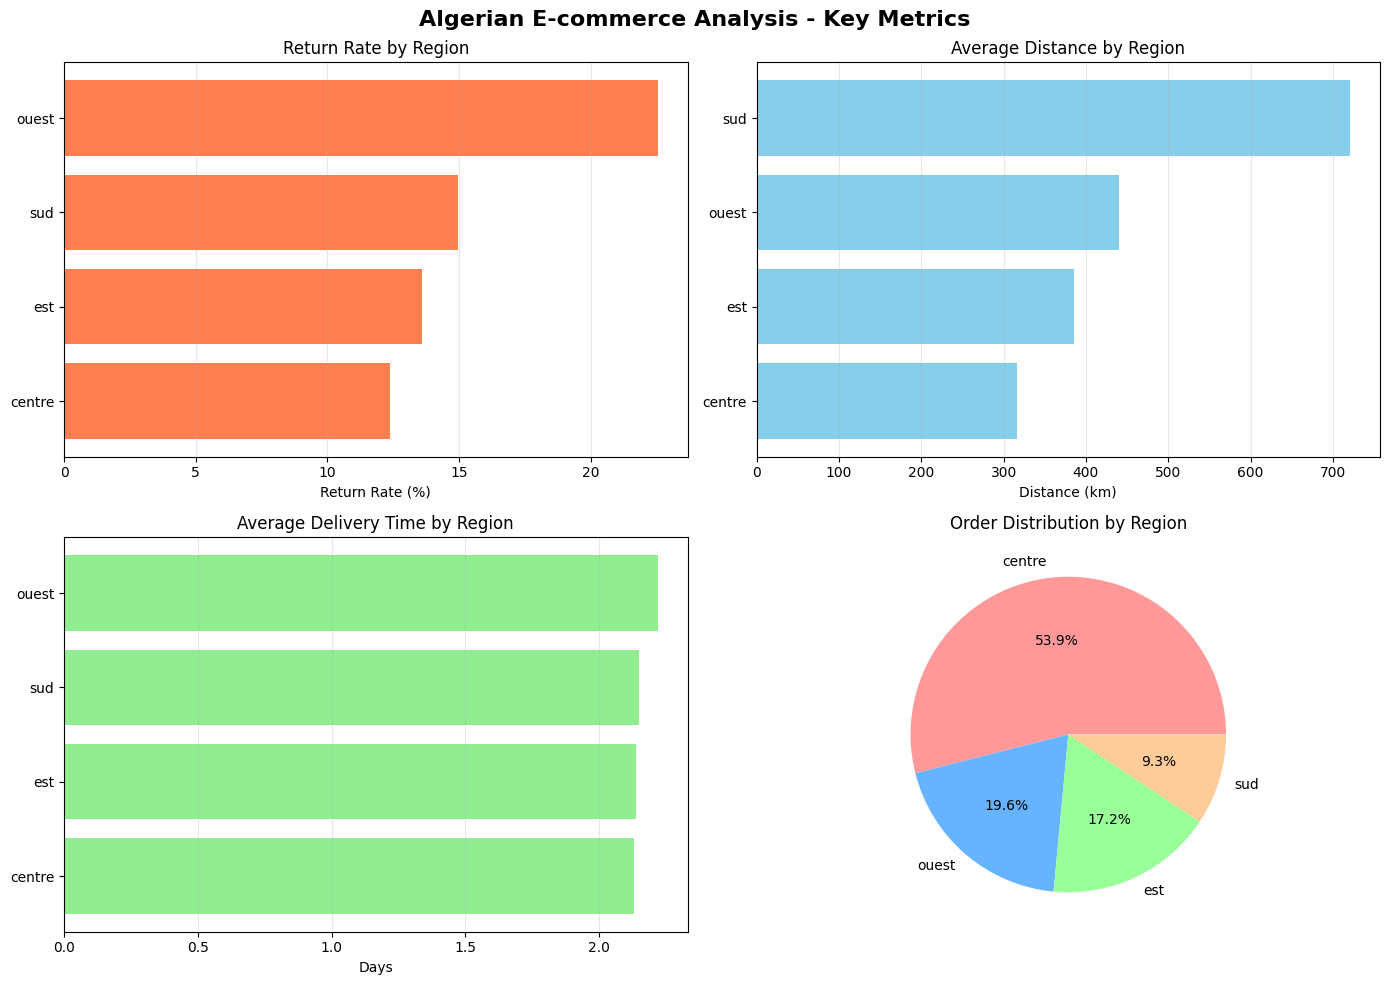

Visualizations created successfully!


In [49]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Algerian E-commerce Analysis - Key Metrics', fontsize=16, fontweight='bold')

# 1. Return Rate by Region
ax1 = axes[0, 0]
return_by_region_sorted = return_by_region.sort_values('Return Rate %', ascending=True)
ax1.barh(return_by_region_sorted.index, return_by_region_sorted['Return Rate %'], color='coral')
ax1.set_xlabel('Return Rate (%)')
ax1.set_title('Return Rate by Region')
ax1.grid(axis='x', alpha=0.3)

# 2. Average Distance by Region
ax2 = axes[0, 1]
avg_distance_by_region_sorted = avg_distance_by_region.sort_values('Avg Distance (km)', ascending=True)
ax2.barh(avg_distance_by_region_sorted.index, avg_distance_by_region_sorted['Avg Distance (km)'], color='skyblue')
ax2.set_xlabel('Distance (km)')
ax2.set_title('Average Distance by Region')
ax2.grid(axis='x', alpha=0.3)

# 3. Average Delivery Time by Region
ax3 = axes[1, 0]
avg_time_by_region_sorted = avg_time_by_region.sort_values('Avg Time (days)', ascending=True)
ax3.barh(avg_time_by_region_sorted.index, avg_time_by_region_sorted['Avg Time (days)'], color='lightgreen')
ax3.set_xlabel('Days')
ax3.set_title('Average Delivery Time by Region')
ax3.grid(axis='x', alpha=0.3)

# 4. Order distribution by Region
ax4 = axes[1, 1]
region_counts = df['region'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
ax4.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', colors=colors)
ax4.set_title('Order Distribution by Region')

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

## 7. Export Results to CSV

In [50]:
# Export analysis results to CSV files
output_folder = '.'

# Export return rate by wilaya
return_by_wilaya.to_csv(f'{output_folder}/analysis_return_rate_by_wilaya.csv')

# Export return rate by region
return_by_region.to_csv(f'{output_folder}/analysis_return_rate_by_region.csv')

# Export average distance by wilaya
avg_distance_by_wilaya.to_csv(f'{output_folder}/analysis_avg_distance_by_wilaya.csv')

# Export average distance by region
avg_distance_by_region.to_csv(f'{output_folder}/analysis_avg_distance_by_region.csv')

# Export average time by wilaya
avg_time_by_wilaya.to_csv(f'{output_folder}/analysis_avg_delivery_time_by_wilaya.csv')

# Export average time by region
avg_time_by_region.to_csv(f'{output_folder}/analysis_avg_delivery_time_by_region.csv')

# Export distance matrix
distance_matrix.to_csv(f'{output_folder}/distance_matrix_between_wilayas.csv')

# Export summary
summary_export = pd.DataFrame({
    'Metric': ['Overall Return Rate (%)', 'Overall Avg Distance (km)', 'Overall Avg Delivery Time (days)'],
    'Value': [return_rate, avg_distance, avg_time]
})
summary_export.to_csv(f'{output_folder}/analysis_summary.csv', index=False)

print("✓ Results exported successfully!")
print(f"\nGenerated files:")
print("  - analysis_return_rate_by_wilaya.csv")
print("  - analysis_return_rate_by_region.csv")
print("  - analysis_avg_distance_by_wilaya.csv")
print("  - analysis_avg_distance_by_region.csv")
print("  - analysis_avg_delivery_time_by_wilaya.csv")
print("  - analysis_avg_delivery_time_by_region.csv")
print("  - distance_matrix_between_wilayas.csv")
print("  - analysis_summary.csv")

✓ Results exported successfully!

Generated files:
  - analysis_return_rate_by_wilaya.csv
  - analysis_return_rate_by_region.csv
  - analysis_avg_distance_by_wilaya.csv
  - analysis_avg_distance_by_region.csv
  - analysis_avg_delivery_time_by_wilaya.csv
  - analysis_avg_delivery_time_by_region.csv
  - distance_matrix_between_wilayas.csv
  - analysis_summary.csv
